In [2]:
import pandas as pd
df = pd.read_csv("../data/spotify_tracks.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (114000, 21)

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [5]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
print("total songs:",len(df))
print("Unique artists:",df["artists"].nunique())

total songs: 114000
Unique artists: 31437


In [7]:
artist_count=df["artists"].value_counts().head(10)
artist_count


artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [8]:
top_songs = df[["track_name","artists","popularity"]].sort_values(
    by="popularity",
    ascending=False
).head(10)

top_songs

,track_name,artists,popularity
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
89411,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
88410,La Bachata,Manuel Turizo,98
67356,La Bachata,Manuel Turizo,98
68303,La Bachata,Manuel Turizo,98


In [9]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

correlation = df[audio_features + ["popularity"]].corr()["popularity"].sort_values(
    ascending = False
)
correlation

popularity          1.000000
loudness            0.050423
danceability        0.035448
tempo               0.013205
energy              0.001056
liveness           -0.005387
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

In [10]:
genre_popularity = (
    df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10)
)
genre_popularity

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

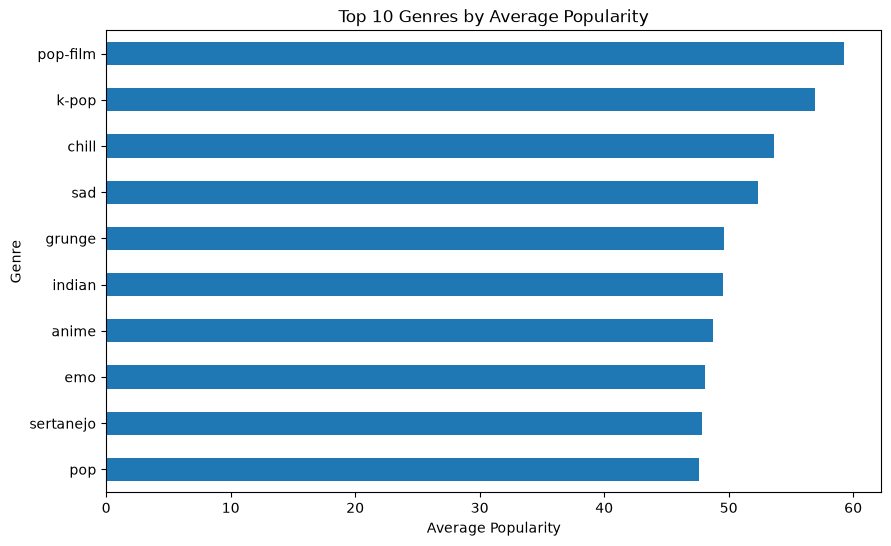

In [11]:

import matplotlib.pyplot as plt
genre_popularity.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Top 10 Genres by Average Popularity"
)
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [13]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


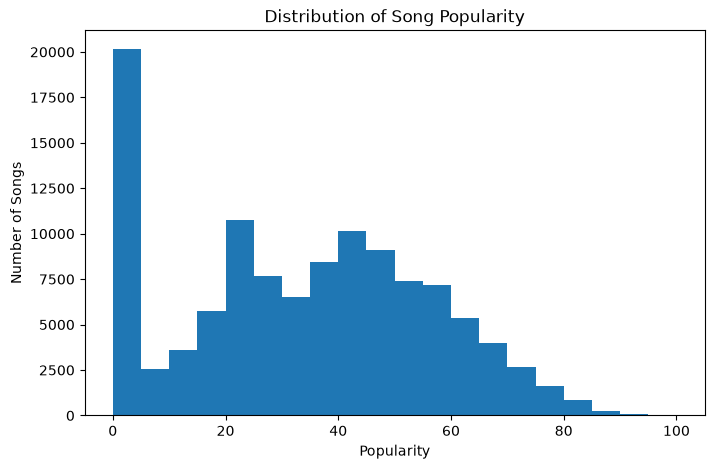

In [16]:
df["popularity"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 5),
    title="Distribution of Song Popularity"
)

plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

In [17]:
df["popularity"].describe()

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [18]:
def popularity_category(popularity):
    if popularity < 40:
        return "low"
    elif popularity < 70:
        return "medium"
    else:
        return "high"
df["popularity_category"] = df["popularity"].apply(popularity_category)
df["popularity_category"].value_counts()

popularity_category
low       65413
medium    43115
high       5472
Name: count, dtype: int64

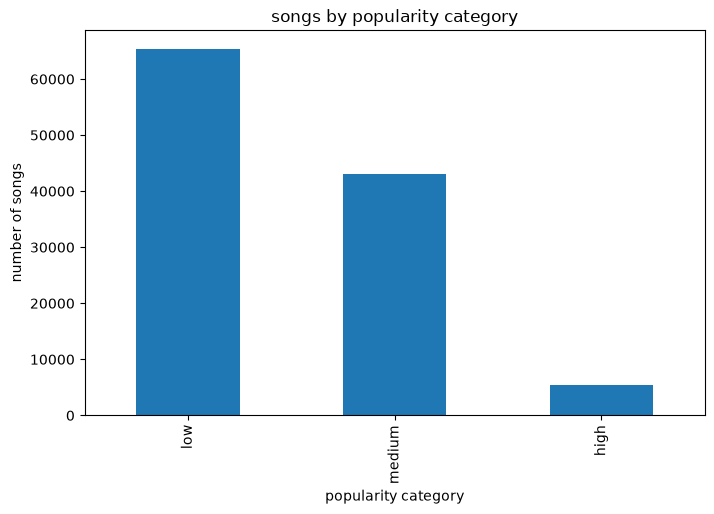

In [20]:
df["popularity_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="songs by popularity category"
)
plt.xlabel("popularity category")
plt.ylabel("number of songs")
plt.show()

In [21]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df.groupby("popularity_category")[audio_features].mean()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity_category,,,,,,,,,
high,0.616051,0.671062,-6.663338,0.075320,0.221188,0.036544,0.171987,0.504489,120.133624
low,0.557497,0.648750,-8.447260,0.091812,0.316521,0.180030,0.217573,0.486267,122.025310
medium,0.574664,0.626439,-8.175788,0.074974,0.324361,0.134835,0.212728,0.451699,122.589370


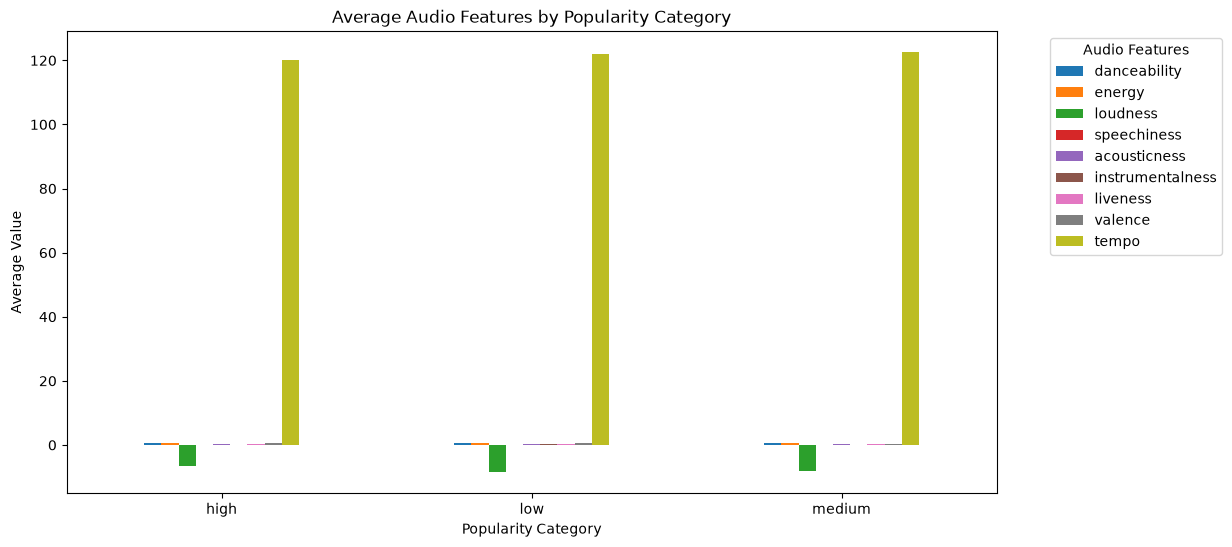

In [22]:
feature_means = df.groupby("popularity_category")[audio_features].mean()

feature_means.plot(
    kind="bar",
    figsize=(12, 6),
    title="Average Audio Features by Popularity Category"
)

plt.xlabel("Popularity Category")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Audio Features", bbox_to_anchor=(1.05, 1))
plt.show()

In [23]:
artist_count=df["artists"].value_counts().head(10)
artist_count

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

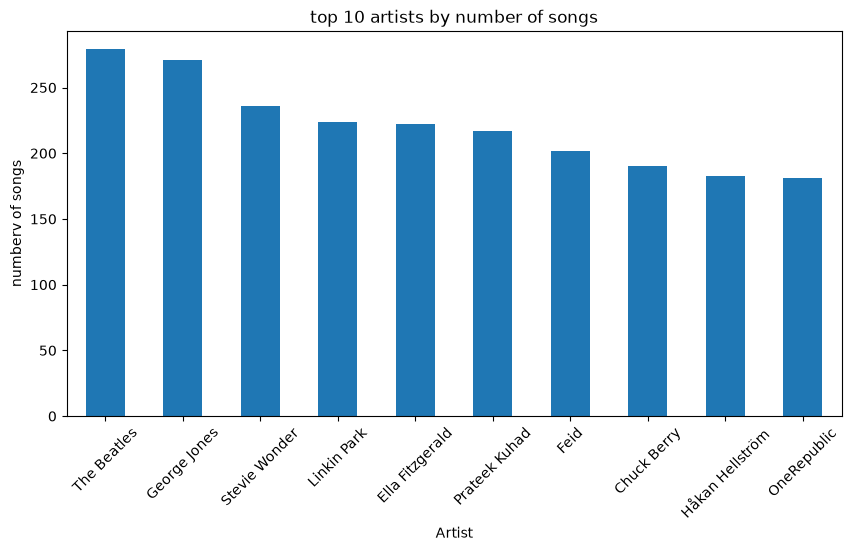

In [24]:
artist_count.plot(
    kind="bar",
    figsize=(10,5),
    title="top 10 artists by number of songs"
)
plt.xlabel("Artist")
plt.ylabel("numberv of songs")
plt.xticks(rotation=45)
plt.show()

In [25]:
artist_popularity = (
    df.groupby("artists")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

artist_popularity

artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Rema;Selena Gomez               92.0
Harry Styles                    92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64

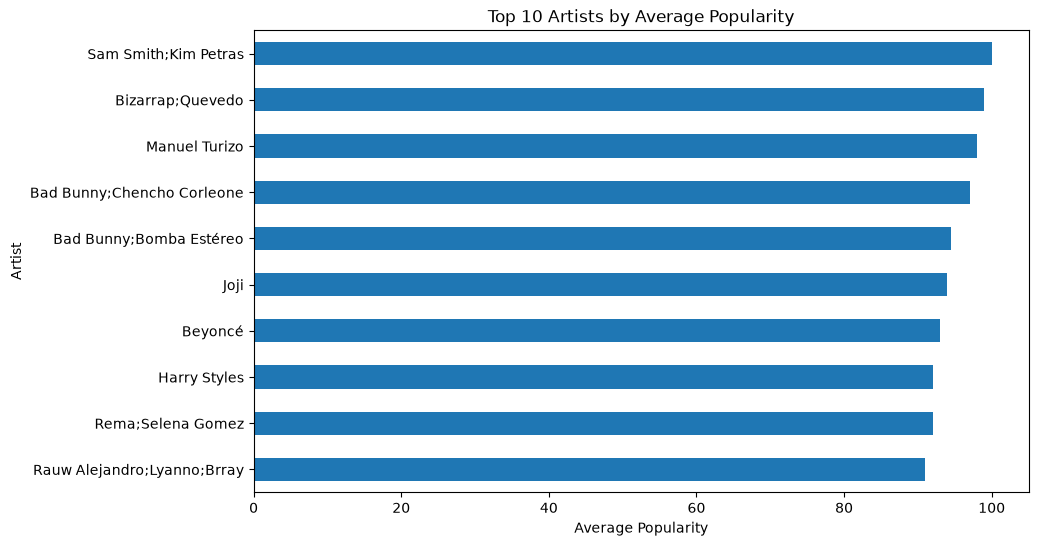

In [26]:
artist_popularity.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Artists by Average Popularity"
)

plt.xlabel("Average Popularity")
plt.ylabel("Artist")
plt.show()

In [27]:
genre_counts = df["track_genre"].value_counts().head(10)

genre_counts


track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

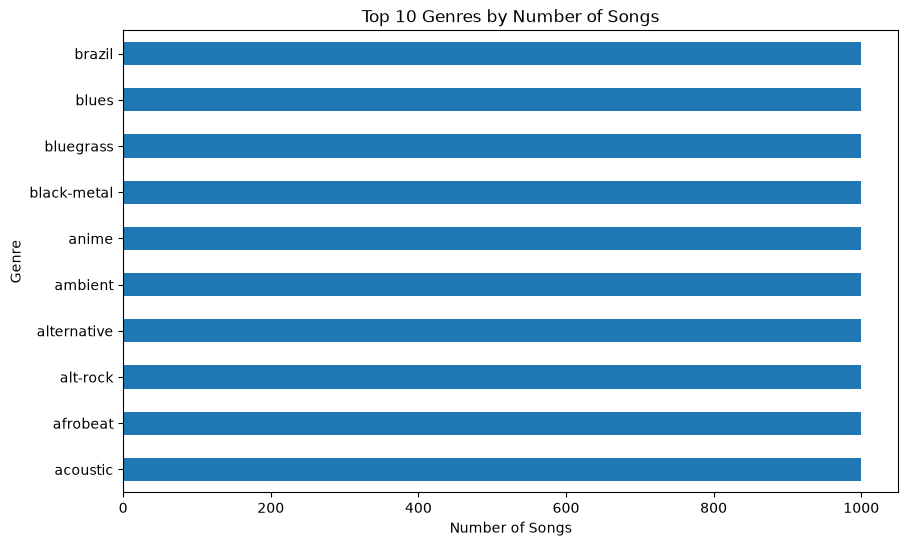

In [28]:
genre_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Genres by Number of Songs"
)

plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.show()

In [29]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

genre_popularity

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

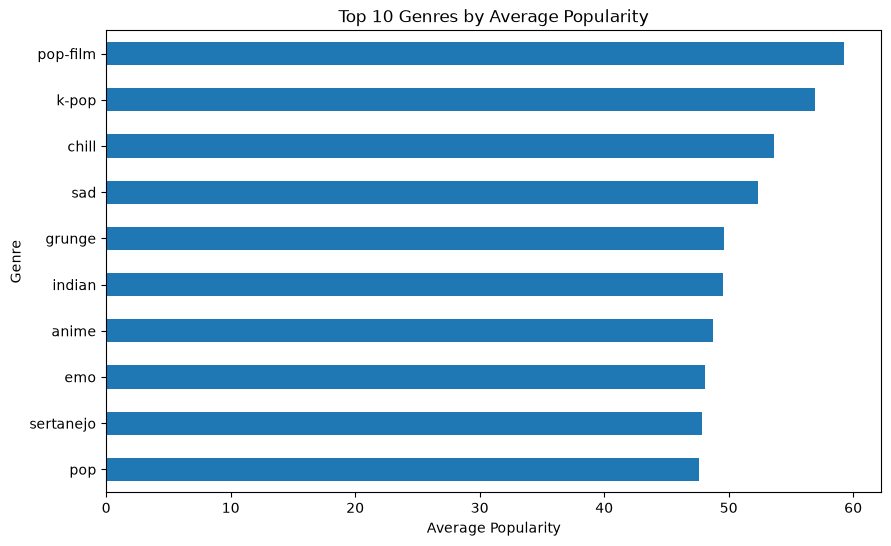

In [30]:
genre_popularity.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Genres by Average Popularity"
)

plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()


In [31]:
correlation_matrix = df[audio_features].corr()

correlation_matrix

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
danceability,1.000000,0.134325,0.259077,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450
energy,0.134325,1.000000,0.761690,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851
loudness,0.259077,0.761690,1.000000,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446
speechiness,0.108626,0.142509,0.060826,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273
acousticness,-0.171533,-0.733906,-0.589803,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224
instrumentalness,-0.185606,-0.181879,-0.433477,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330
liveness,-0.131617,0.184796,0.076899,0.205219,-0.020700,-0.079893,1.000000,0.019086,0.000600
valence,0.477341,0.258934,0.279848,0.036635,-0.107070,-0.324312,0.019086,1.000000,0.078273
tempo,-0.050450,0.247851,0.212446,0.017273,-0.208224,-0.050330,0.000600,0.078273,1.000000


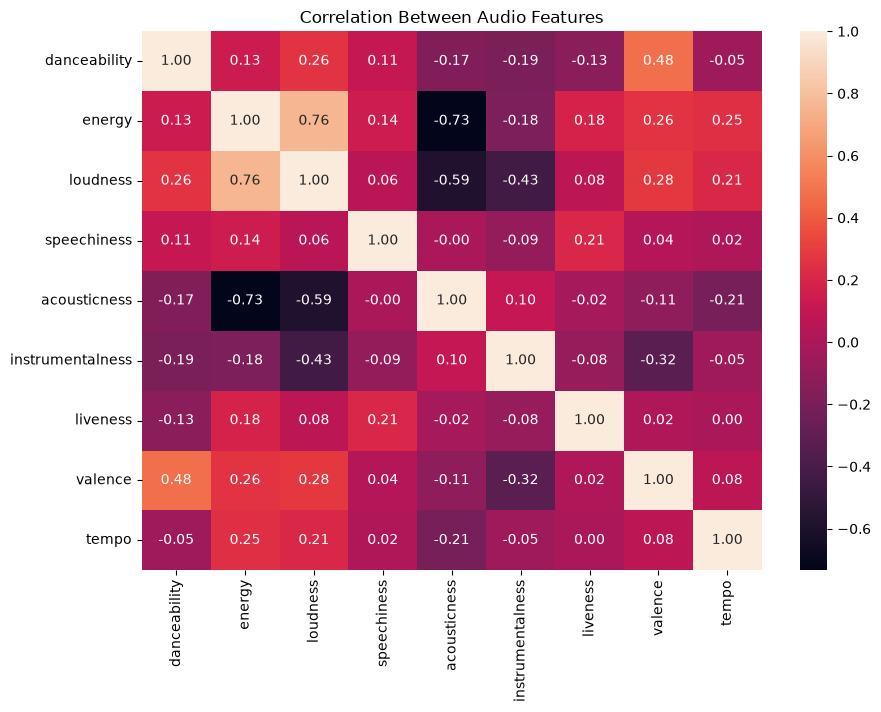

In [33]:
import seaborn as sns
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Audio Features")
plt.show()

In [34]:
popularity_correlation = (
    df[audio_features + ["popularity"]]
    .corr()["popularity"]
    .drop("popularity")
    .sort_values()
)

popularity_correlation

instrumentalness   -0.095139
speechiness        -0.044927
valence            -0.040534
acousticness       -0.025472
liveness           -0.005387
energy              0.001056
tempo               0.013205
danceability        0.035448
loudness            0.050423
Name: popularity, dtype: float64

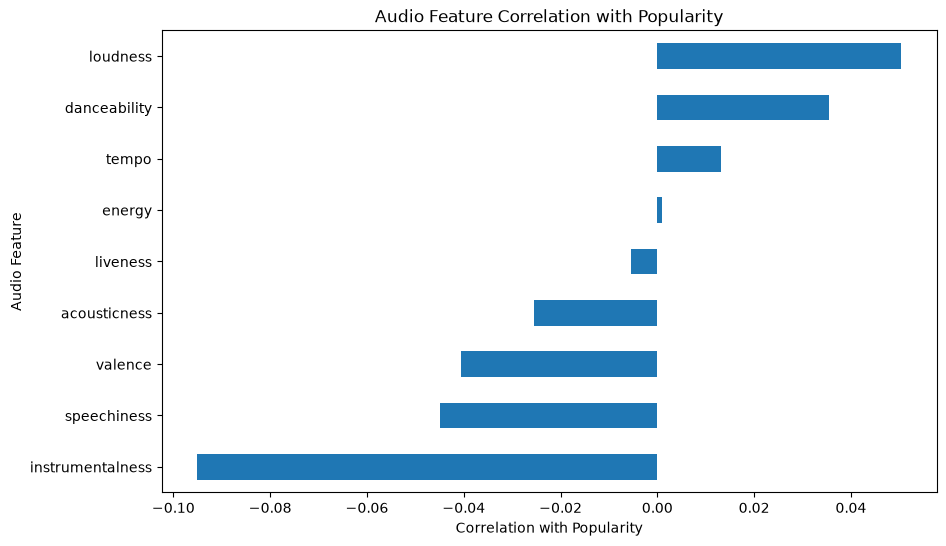

In [35]:
popularity_correlation.plot(
    kind="barh",
    figsize=(10, 6),
    title="Audio Feature Correlation with Popularity"
)

plt.xlabel("Correlation with Popularity")
plt.ylabel("Audio Feature")
plt.show()


In [36]:
top_10_songs = (
    df[["track_name", "artists", "track_genre", "popularity"]]
    .sort_values(by="popularity", ascending=False)
    .head(10)
)

top_10_songs

,track_name,artists,track_genre,popularity
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
89411,La Bachata,Manuel Turizo,reggaeton,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98
88410,La Bachata,Manuel Turizo,reggae,98
67356,La Bachata,Manuel Turizo,latin,98
68303,La Bachata,Manuel Turizo,latino,98


In [37]:
top_10_features = top_10_songs.merge(
    df[audio_features + ["track_name"]],
    on="track_name",
    how="left"
)

top_10_features


,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100,0.714,0.472,-7.375,0.0864,0.0130,0.000005,0.266,0.238,131.121
1,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100,0.714,0.472,-7.375,0.0864,0.0130,0.000005,0.266,0.238,131.121
2,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,0.714,0.472,-7.375,0.0864,0.0130,0.000005,0.266,0.238,131.121
3,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,0.714,0.472,-7.375,0.0864,0.0130,0.000005,0.266,0.238,131.121
4,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99,0.621,0.782,-5.548,0.0440,0.0125,0.033000,0.230,0.550,128.033
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,La Bachata,Manuel Turizo,latin,98,0.835,0.679,-5.329,0.0364,0.5830,0.000002,0.218,0.850,124.980
71,La Bachata,Manuel Turizo,latino,98,0.835,0.679,-5.329,0.0364,0.5830,0.000002,0.218,0.850,124.980
72,La Bachata,Manuel Turizo,latino,98,0.835,0.679,-5.329,0.0364,0.5830,0.000002,0.218,0.850,124.980
73,La Bachata,Manuel Turizo,latino,98,0.835,0.679,-5.329,0.0364,0.5830,0.000002,0.218,0.850,124.980


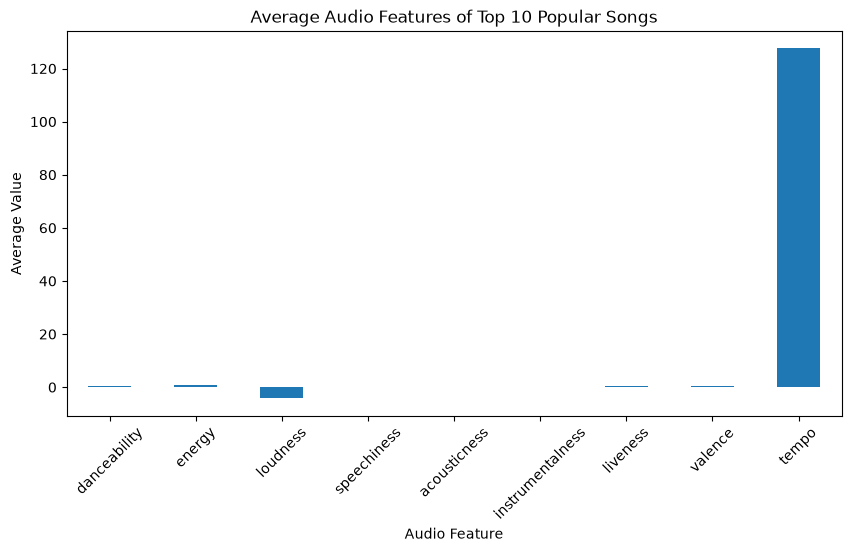

In [38]:
top_10_features[audio_features].mean().plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Audio Features of Top 10 Popular Songs"
)

plt.xlabel("Audio Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

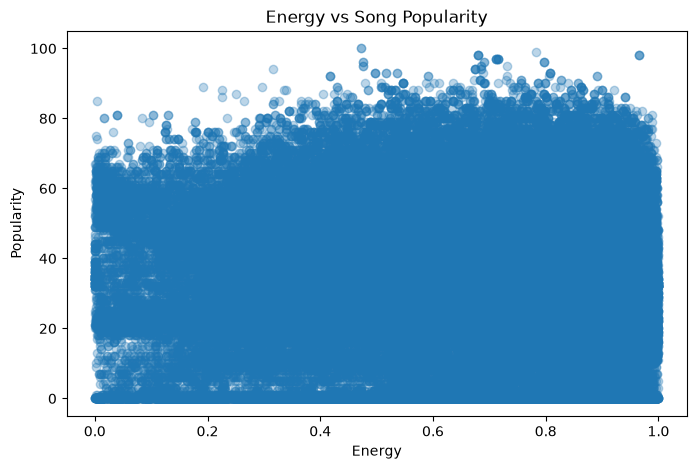

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["energy"],
    df["popularity"],
    alpha=0.3
)

plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy vs Song Popularity")
plt.show()


## Day 2 — Advanced EDA Insights

### Popularity Analysis
- Songs were divided into Low, Medium, and High popularity categories.
- The distribution of songs across these categories was visualized.

### Audio Feature Analysis
- Compared average audio features across popularity categories.
- Analyzed features such as danceability, energy, valence, acousticness, and instrumentalness.

### Artist Analysis
- Identified the top 10 artists by number of songs.
- Analyzed artists with the highest average song popularity.

### Genre Analysis
- Identified the most represented genres in the dataset.
- Compared genres based on their average popularity.

### Correlation Analysis
- Created a correlation matrix for Spotify audio features.
- Visualized relationships between audio features using a heatmap.
- Analyzed the correlation between audio features and song popularity.

### Popular Songs
- Identified the top 10 most popular songs.
- Compared their average audio-feature characteristics.

### Visualization
- Created bar charts, horizontal bar charts, heatmaps, and scatter plots
  to understand patterns in the dataset.

### Key Learning
Advanced EDA helps identify patterns and relationships in the data
before applying machine learning models.